# DARCLOS-TEMPO Cloud Shadow Detection

Adaptation of the DARCLOS algorithm (Trees et al., 2022, AMT 15, 3121–3140) to TEMPO geostationary data.

---

## 1. Paper Review — Trees et al. (2022)

### 1.1 Three-Flag System

DARCLOS produces three hierarchical shadow flags:

| Flag | Name | Definition |
|------|------|------------|
| **PCSF** | Potential Cloud Shadow Flag | Pixel falls within the geometric shadow projection of a cloud pixel (conservative; high recall, low precision) |
| **ACSF** | Actual Cloud Shadow Flag | PCSF pixel additionally confirmed by spectral darkening: scene reflectance is >15% darker than the DLER climatology at the wavelength of maximum DLER (λ_max) |
| **SCSF** | Spectral Cloud Shadow Flag | ACSF computed independently at each DLER wavelength (328–494+ nm), enabling wavelength-resolved shadow detection for each trace-gas retrieval window |

### 1.2 PCSF — Shadow Projection Geometry (Eqs. 1–7)

**Step 1 — Effective cloud height** (Eq. 1):
$$h = (1 + C)(h_c - h_{\rm sfc})$$
- $h_c$ = FRESCO cloud top height (or OCP-based approximation for TEMPO)
- $h_{\rm sfc}$ = terrain height
- $C = 0.5$ = safety factor (reduces false negatives by enlarging shadow projection)

**Step 2 — Parallax correction** (Eqs. 2–3): The cloud at height $h$ above a surface pixel is displaced from the pixel's nadir by the viewing geometry. In local East–North coordinates:
$$x_n = h \tan(\theta_{\rm VZA}) \sin(\psi_{\rm VAA}), \quad y_n = h \tan(\theta_{\rm VZA}) \cos(\psi_{\rm VAA})$$

**Step 3 — Solar shadow displacement** (Eqs. 4–5): The shadow tip Q is displaced from the cloud nadir P by:
$$x_{\rm sh} = x_n - h \tan(\theta_{\rm SZA}) \sin(\phi_{\rm SAA}), \quad y_{\rm sh} = y_n - h \tan(\theta_{\rm SZA}) \cos(\phi_{\rm SAA})$$

**Step 4 — Geodetic conversion** (Eqs. 6–7):
$$\Delta\phi \approx y_{\rm sh} / (M + h_{\rm sfc}), \quad \Delta\lambda \approx x_{\rm sh} / [(N + h_{\rm sfc}) \cos \phi_c]$$
where $M \approx N \approx 6{,}378{,}137$ m (Earth's radii of curvature). Simplified to:
$$\Delta\phi\,[°] \approx y_{\rm sh}^{\rm km} / 111.32, \quad \Delta\lambda\,[°] \approx x_{\rm sh}^{\rm km} / (111.32 \cos\phi_c)$$

**PCSF flagging**: All shadow-candidate pixels whose centers fall inside the **triangle OPQ** (convex hull of the 4 projected cloud pixel corners) are flagged PCSF. This requires iterating the projection over the cloud pixel's 4 corner footprints.

### 1.3 ACSF — Radiometric Confirmation (Eqs. 10–13)

**SCNLER** (Scene Normalized LER, Eq. 10) — the Lambertian-equivalent surface reflectance derived from the measured TOA radiance after Rayleigh correction:
$$A_{\rm scene}(\lambda) = \frac{R^{\rm meas}(\lambda) - R^0(\lambda)}{T(\lambda) + s^*(\lambda)T^{\rm meas}(\lambda) - R^0(\lambda)}$$

**Contrast** (Eq. 11):
$$\Gamma(\lambda) = \frac{A_{\rm scene}(\lambda) - A_{\rm DLER}(\lambda)}{A_{\rm DLER}(\lambda)} \times 100\%$$

**Wavelength selection** (Eq. 12): $\lambda_{\rm max} = \arg\max_\lambda A_{\rm DLER}(\lambda)$ — the wavelength where DLER is maximum minimises sensitivity to DLER errors.

**ACSF raised** (Eq. 13) when: $\Gamma(\lambda_{\rm max}) < q = -15\%$

### 1.4 SCSF — Spectral Version

Same as ACSF but $\Gamma(\lambda) < -15\%$ evaluated independently at each of the 13+ DLER wavelengths (328, 335, 340, 354, 367, 380, 388, 402, 416, 425, 440, 463, 494 nm in the UV–VIS range). Enables per-retrieval-window shadow flags (NO₂, HCHO, SO₂).

### 1.5 Key Algorithm Parameters

| Parameter | Value | Source |
|-----------|-------|--------|
| Safety factor $C$ | 0.5 | Trees et al. (2022), tuned to minimise omission error |
| ACSF/SCSF threshold $q$ | −15% | Trees et al. (2022), empirically validated |
| Cloud flag threshold (ECF) | ~0.05–0.2 | Paper uses 'raised cloud flag'; ~ECF ≥ 0.05 |
| Validation metric | F₁ ≥ 0.84–0.95 | Table 1, 7 case studies |


---

## 2. Assessment of Existing Notebook (`Cloud Shadows Masking-Debug.ipynb`)

| Component | Paper specification | Existing notebook | Status |
|-----------|--------------------|--------------------|--------|
| PCSF shadow area | All pixels inside triangle OPQ (4 cloud corners projected to shadow tips, convex hull) | Bresenham 1-pixel-wide line from cloud center to shadow center | **Partial — misses shadow width** |
| Safety factor C | $h = (1+C)(h_c - h_{\rm sfc})$, $C=0.5$, applied to effective height | `C=0.5` defined but overridden: active code path sets `h = z` (OCP formula) directly, bypassing C | **Bug — C not applied** |
| Cloud height | FRESCO/OCP height converted via meteorological profile | OCP hypsometric `z = 8000·ln(p_sfc/p)` clipped to 8 km (not 20 km), or falls back to hardcoded 15 km | **Partial — scale height 8000 m, 8 km cap, no C applied** |
| Cloud source threshold | ECF ≥ ~0.05 (raised cloud flag) | `cloud_threshold = 0.30` (default) | **Stricter than paper; configurable** |
| ACSF (radiometric) | $\Gamma(\lambda_{\rm max}) < -15\%$ comparing SCNLER to DLER climatology | **Not implemented.** Replaced by: candidate pixels where `cloud_fraction < 0.05` | **Critical gap — no spectral check** |
| SCSF (per-wavelength) | $\Gamma(\lambda) < -15\%$ at 13 UV–VIS wavelengths | Not implemented | **Missing entirely** |
| DLER climatology | Tilstra (2022) 21-wavelength monthly DLER at 0.125° grid | Not loaded. SCNLER never computed from L1B radiance | **Missing** |
| Output flags | `pcsf`, `acsf`, `scsf`, `scsf_no2`, `scsf_hcho`, `scsf_so2` | Binary masks: `cloud_mask`, `potential_mask`, `actual_mask` | **Schema mismatch** |

### Key Errors and Scientific Consequences

1. **No ACSF** (most consequential): The notebook's `actual_mask` is simply pixels where ECF < 0.05 that overlap the geometric shadow line. This confounds *geographically clear* pixels with *radiometrically confirmed shadow* pixels — topographic darkening, aerosol loading, or low-reflectance surfaces (dark water, forests) would all pass this filter falsely.

2. **Bresenham line instead of triangle**: At TEMPO resolution (~2 km × 4.75 km), a cloud pixel at 5 km height with SZA=70° casts a shadow displaced ~14 km but the shadow footprint width equals the cloud pixel width (~5 km = ~1 TEMPO pixel). The line approximation misses at most 1–2 pixels of width — less severe than the ACSF gap, but still a source of omission error.

3. **Safety factor C not applied**: The effective height should be 1.5× the cloud-surface height difference to reduce false negatives; the notebook uses the raw OCP height, producing a smaller shadow triangle than intended.

4. **Hardcoded 15 km fallback**: When `cloud_top_height` is fill-valued (as in all 4 current L1B files), the notebook falls back silently to 15 km, which is in the stratosphere and physically implausible for boundary-layer or low convective clouds.


---

## 3. DARCLOS-TEMPO Implementation


In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [2]:
# ============================================================
# DARCLOS-TEMPO Configuration
# All parameters are named constants — no magic numbers inline.
# Sources cited per parameter.
# ============================================================

# --- File paths (relative to notebooks/ directory) ---
L1B_DIR = Path("../data/raw_l1")
L2_DIR  = Path("../data/raw_l2_v3")   # V03 is the primary dataset for this run

# --- Granule pairs: (l1b_filename, l2_filename) ---
GRANULE_PAIRS = [
    (
        "TEMPO_RAD_L1_V04_20250909T115202Z_S002G02.nc",
        "TEMPO_CLDO4_L2_V03_20250909T115202Z_S002G02.nc",
    ),
    (
        "TEMPO_RAD_L1_V04_20250909T115842Z_S002G03.nc",
        "TEMPO_CLDO4_L2_V03_20250909T115842Z_S002G03.nc",
    ),
    (
        "TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc",
        "TEMPO_CLDO4_L2_V03_20250909T125205Z_S003G05.nc",
    ),
    (
        "TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc",
        "TEMPO_CLDO4_L2_V03_20250909T231218Z_S014G02.nc",
    ),
]
ACTIVE_GRANULE_IDX = 0   # Change to process a different granule

# --- DARCLOS algorithm parameters ---
# Safety factor — reduces false negatives by enlarging shadow projection
# Source: Trees et al. (2022) Eq. 1; tuned to minimise omission error
SAFETY_FACTOR_C = 0.5

# ACSF contrast threshold q
# Source: Trees et al. (2022) Eq. 13; empirically validated at q = -15%
ACSF_CONTRAST_THRESH = -0.15

# ECF threshold for cloud source pixels (shadow casters)
# Source: TEMPO NO2 ATBD; consistent with CLDO4 V03 positive bias
ECF_SOURCE_THRESH = 0.20

# ECF threshold for shadow candidate pixels (clear-sky requirement)
# V03 has a positive ECF bias of ~0.05-0.10: the minimum observed ECF in
# quality-filtered clear-sky pixels is ~0.057 (P01). ECF < 0.05 yields zero
# candidates in V03. Threshold raised to 0.10 to capture the lowest-ECF pixels
# as clear-sky proxies. Switch to V04 for threshold = 0.05 to be valid.
ECF_CANDIDATE_THRESH = 0.10

# Maximum solar zenith angle — consistent with TEMPO L2 QA
SZA_MAX_DEG = 75.0

# Hypsometric scale height — used when L1B cloud_top_height is fill-valued
# Standard atmosphere approximation; not traceable to a DARCLOS parameter
SCALE_HEIGHT_M = 8500.0

# --- Visualization ---
PATCH_SIZE      = 256    # Cross-track window width [pixels]
SHADOW_FRAC_MIN = 0.01   # Minimum PCSF pixel fraction to display a patch
MAX_PATCHES     = 6      # Maximum number of diagnostic patches per granule

# Pixel-index search buffer around estimated shadow center
# Should be large enough to contain the shadow polygon in pixel space
SEARCH_BUFFER = 15

# --- Grid dimensions (TEMPO granule) ---
N_MIRROR_STEPS = 132
N_XTRACK       = 2048

In [12]:
def load_granule(l1b_path: Path, l2_path: Path) -> dict:
    """Load all DARCLOS-TEMPO inputs from one L1B + L2 file pair.

    Parameters
    ----------
    l1b_path : Path
        TEMPO L1B radiance file (TEMPO_RAD_L1_V04_*.nc)
    l2_path : Path
        TEMPO L2 CLDO4 cloud product (TEMPO_CLDO4_L2_V03_*.nc)

    Returns
    -------
    dict with keys (all float32 arrays of shape (132, 2048) unless noted):
        lat, lon                  [degrees]
        lat_bounds, lon_bounds    [degrees] shape (132, 2048, 4)
        sza, saa, vza, vaa        [degrees]
        cloud_fraction            [dimensionless]
        cloud_pressure            [hPa]
        processing_quality_flag   [int, 0=good]
        terrain_height            [m]
        surface_pressure          [hPa]
        scene_ler_466             [dimensionless]
        scene_ler_440             [dimensionless]
        gler_466                  [dimensionless]
        gler_440                  [dimensionless]
        snow_ice_fraction         [dimensionless]
        cloud_height              [m]  (L1B CTH or OCP hypsometric fallback)
        rgb_red, rgb_green, rgb_blue  [0–1, gamma-corrected]

    Raises
    ------
    FileNotFoundError
        If either input file does not exist.
    ValueError
        If a required variable is absent or has an unexpected shape.
    """
    if not l1b_path.exists():
        raise FileNotFoundError(f"L1B file not found: {l1b_path}")
    if not l2_path.exists():
        raise FileNotFoundError(f"L2 file not found: {l2_path}")

    def _load_var(grp, name: str, fill: float = np.nan) -> np.ndarray:
        """Load variable from netCDF4 group, filling masked values."""
        if name not in grp.variables:
            raise ValueError(
                f"Variable '{name}' not found in group '{grp.path}' "
                f"of file '{grp.filepath()}'"
            )
        return np.ma.filled(grp.variables[name][:].astype(np.float32), fill)

    def _assert_shape(arr: np.ndarray, expected: tuple, name: str) -> None:
        if arr.shape != expected:
            raise ValueError(
                f"Variable '{name}' has shape {arr.shape}, expected {expected}"
            )

    expected_2d = (N_MIRROR_STEPS, N_XTRACK)
    data = {}

    with nc.Dataset(str(l2_path)) as l2:
        geo  = l2["geolocation"]
        prod = l2["product"]
        supp = l2["support_data"]

        data["lat"]                     = _load_var(geo,  "latitude")
        data["lon"]                     = _load_var(geo,  "longitude")
        data["lat_bounds"]              = _load_var(geo,  "latitude_bounds")
        data["lon_bounds"]              = _load_var(geo,  "longitude_bounds")
        # NOTE: solar/viewing angles are NOT loaded from L2 geolocation here.
        # In V03, viewing_azimuth_angle is entirely fill-valued and
        # solar_azimuth_angle is 93.8% fill-valued in L2.
        # Angles are instead loaded from the L1B band_290_490_nm group below,
        # which has full (270336) valid values for all four angle variables.
        data["cloud_fraction"]          = _load_var(prod, "cloud_fraction")
        data["cloud_pressure"]          = _load_var(prod, "cloud_pressure")
        data["processing_quality_flag"] = _load_var(prod, "processing_quality_flag",
                                                    fill=9999.0)
        data["terrain_height"]          = _load_var(supp, "terrain_height")
        data["surface_pressure"]        = _load_var(supp, "surface_pressure")
        data["scene_ler_466"]           = _load_var(supp, "SceneLER466")
        data["scene_ler_440"]           = _load_var(supp, "SceneLER440")
        data["gler_466"]                = _load_var(supp, "GLER466")
        data["gler_440"]                = _load_var(supp, "GLER440")
        data["snow_ice_fraction"]       = _load_var(supp, "snow_ice_fraction")

    # Assert 2-D shapes for all spatial arrays
    for key in [
        "lat", "lon",
        "cloud_fraction", "cloud_pressure", "processing_quality_flag",
        "terrain_height", "surface_pressure",
        "scene_ler_466", "scene_ler_440", "gler_466", "gler_440",
        "snow_ice_fraction",
    ]:
        _assert_shape(data[key], expected_2d, key)
    _assert_shape(data["lat_bounds"], (N_MIRROR_STEPS, N_XTRACK, 4), "lat_bounds")
    _assert_shape(data["lon_bounds"], (N_MIRROR_STEPS, N_XTRACK, 4), "lon_bounds")

    with nc.Dataset(str(l1b_path)) as l1b:
        band = l1b["band_290_490_nm"]
        cmg  = l1b["cloud_mask_group"]

        # --- Solar and viewing angles (loaded from L1B — L2 angles fill-valued) ---
        # L2 geolocation/viewing_azimuth_angle: 0 valid values (entirely fill-valued)
        # L2 geolocation/solar_azimuth_angle: only 6.2% valid, clustering 88.8–90.0°
        # L1B band_290_490_nm: all four angles fully valid (270336/270336 pixels)
        data["sza"] = _load_var(band, "solar_zenith_angle")
        data["saa"] = _load_var(band, "solar_azimuth_angle")
        data["vza"] = _load_var(band, "viewing_zenith_angle")
        data["vaa"] = _load_var(band, "viewing_azimuth_angle")
        for key in ["sza", "saa", "vza", "vaa"]:
            _assert_shape(data[key], expected_2d, key)
            n_valid = int(np.sum(np.isfinite(data[key])))
            if n_valid == 0:
                raise ValueError(
                    f"L1B '{key}' is entirely fill-valued — cannot compute shadows."
                )

        # --- Cloud top height (fill-valued in all V04 L1B files) ---
        cth_raw = _load_var(band, "cloud_top_height")
        _assert_shape(cth_raw, expected_2d, "cloud_top_height")

        finite_frac = float(np.mean(np.isfinite(cth_raw)))
        if finite_frac < 0.01:
            print("=" * 70)
            print("WARNING: cloud_top_height is entirely fill-valued in this L1B file.")
            print(f"  Finite fraction: {finite_frac:.4f}")
            print("Falling back to OCP-based hypsometric approximation:")
            print(f"  h_c = {SCALE_HEIGHT_M:.0f} m * ln(surface_pressure / cloud_pressure)")
            print("This is an approximation. PCSF shadow heights are indicative only.")
            print("=" * 70)
            
            with np.errstate(divide="ignore", invalid="ignore"):
                h_c = SCALE_HEIGHT_M * np.log(
                    data["surface_pressure"] / data["cloud_pressure"]
                )
            h_c = np.where(np.isfinite(h_c), h_c, np.nan)
            h_c = np.clip(h_c, 0.0, 8000.0)
        else:
            h_c = cth_raw

        data["cloud_height"] = h_c.astype(np.float32)
        print(h_c)

        # --- RGB composite (gamma-corrected, matches test/netcdf_to_raster.py) ---
        red   = _load_var(cmg, "red")
        green = _load_var(cmg, "green")
        blue  = _load_var(cmg, "blue")
        for name, arr in [("red", red), ("green", green), ("blue", blue)]:
            _assert_shape(arr, expected_2d, name)
        data["rgb_red"]   = np.clip(red,   0.0, 1.0) ** 0.4
        data["rgb_green"] = np.clip(green, 0.0, 1.0) ** 0.4
        data["rgb_blue"]  = np.clip(blue,  0.0, 1.0) ** 0.4

    return data

In [13]:
def build_quality_mask(data: dict) -> np.ndarray:
    """Build a boolean valid-pixel mask for shadow detection.

    True  = pixel is valid for shadow detection.
    False = pixel is excluded.

    Exclusion criteria (any one is sufficient to exclude):
        - SZA >= SZA_MAX_DEG
        - snow_ice_fraction > 0.5
        - processing_quality_flag != 0
        - lat or lon is NaN

    Parameters
    ----------
    data : dict
        Loaded by load_granule().

    Returns
    -------
    np.ndarray of shape (132, 2048), dtype bool
    """
    # Error bits in processing_quality_flag (bitwise; non-error bits are warn/info)
    # bit0=geoloc_error, bit3=psurf_albedo_error, bit6=scd_negative,
    # bit8=466nm_rad_error, bit12=ecf_skipped, bit13=ocp_skipped
    ERROR_BITS = 1 | 8 | 64 | 256 | 4096 | 8192   # = 8621
    pqf_int = data["processing_quality_flag"].astype(np.int32)
    no_error = (pqf_int & ERROR_BITS) == 0

    mask = (
        (data["sza"] < SZA_MAX_DEG)
        & (data["snow_ice_fraction"] <= 0.5)
        & no_error
        & np.isfinite(data["lat"])
        & np.isfinite(data["lon"])
    )
    assert mask.shape == (N_MIRROR_STEPS, N_XTRACK), (
        f"quality_mask shape {mask.shape} != ({N_MIRROR_STEPS}, {N_XTRACK})"
    )
    assert mask.dtype == bool, f"quality_mask dtype {mask.dtype} != bool"
    return mask

In [14]:
def _point_in_polygon(
    px: float, py: float,
    poly_x: np.ndarray, poly_y: np.ndarray
) -> bool:
    """Ray-casting point-in-polygon test for a simple (possibly non-convex) polygon.

    Parameters
    ----------
    px, py : float
        Query point coordinates (lat, lon).
    poly_x, poly_y : np.ndarray
        Polygon vertex latitudes and longitudes (ordered, closed ring not required).

    Returns
    -------
    bool — True if (px, py) is strictly inside the polygon.
    """
    n = len(poly_x)
    inside = False
    j = n - 1
    for i in range(n):
        xi, yi = poly_x[i], poly_y[i]
        xj, yj = poly_x[j], poly_y[j]
        if (yi > py) != (yj > py):
            t = (xj - xi) * (py - yi) / (yj - yi) + xi
            if px < t:
                inside = not inside
        j = i
    return inside


def compute_pcsf(data: dict, quality_mask: np.ndarray) -> np.ndarray:
    """Compute the Potential Cloud Shadow Flag (PCSF).

    For each cloud source pixel (ECF >= ECF_SOURCE_THRESH, quality_mask True),
    the cloud pixel's 4 corner footprints are projected to their shadow positions
    using the full DARCLOS geometry (Trees et al. 2022, Eqs. 1–7):

        1. Effective cloud height with safety factor C (Eq. 1):
           h = (1 + C) * (h_c - h_sfc)
        2. Parallax correction — cloud nadir offset from pixel nadir (Eqs. 2–3):
           dx_parallax = h * tan(VZA) * sin(VAA)  [km, eastward]
           dy_parallax = h * tan(VZA) * cos(VAA)  [km, northward]
        3. Solar shadow displacement from cloud nadir (Eqs. 4–5):
           dx_solar = h * tan(SZA) * sin(SAA)     [km, eastward]
           dy_solar = h * tan(SZA) * cos(SAA)     [km, northward]
        4. Total shadow offset from pixel center (Eqs. 4–5 combined):
           dx = dx_parallax - dx_solar
           dy = dy_parallax - dy_solar
        5. Geodetic conversion (Eqs. 6–7, simplified):
           d_lat = dy / 111.32
           d_lon = dx / (111.32 * cos(lat))
        6. Shadow polygon = cloud pixel's 4 corner footprints shifted by (d_lat, d_lon)
        7. All candidate pixels (ECF < ECF_CANDIDATE_THRESH) whose centers fall
           inside the shadow polygon are flagged PCSF.

    Note: the rigid translation (same d_lat, d_lon for all 4 corners) uses the
    cloud pixel center's angles. This is exact for a point cloud and a good
    approximation for TEMPO's ~2 km x 4.75 km footprint.

    Parameters
    ----------
    data : dict
        Loaded by load_granule().
    quality_mask : np.ndarray
        Bool (132, 2048), from build_quality_mask().

    Returns
    -------
    pcsf : np.ndarray, shape (132, 2048), dtype bool
    """
    assert quality_mask.shape == (N_MIRROR_STEPS, N_XTRACK)

    lat     = data["lat"]
    lon     = data["lon"]
    lat_b   = data["lat_bounds"]   # (132, 2048, 4): corners NE, NW, SW, SE
    lon_b   = data["lon_bounds"]
    sza     = data["sza"]
    saa     = data["saa"]
    vza     = data["vza"]
    vaa     = data["vaa"]
    h_cloud = data["cloud_height"]
    h_sfc   = data["terrain_height"]

    # Precompute Jacobian for pixel-index estimation.
    # TEMPO geometry: xtrack (axis=1, 2048 pixels) spans N-S (~43° lat);
    # mirror_step (axis=0, 132 steps) scans E-W.  Both lat and lon vary along
    # BOTH axes, so a 2D linear system (Jacobian) is required to convert
    # geographic displacement (d_lat, d_lon) → pixel offsets (di, dj).
    #
    # Jacobian components:
    #   J = [[dlat_di, dlat_dj],   det = dlat_di*dlon_dj - dlat_dj*dlon_di
    #        [dlon_di, dlon_dj]]
    # Cramer's rule:
    #   di = (d_lat*dlon_dj - d_lon*dlat_dj) / det
    #   dj = (dlat_di*d_lon - dlon_di*d_lat) / det
    dlat_di = np.gradient(lat, axis=0)   # ∂lat/∂(mirror_step)
    dlat_dj = np.gradient(lat, axis=1)   # ∂lat/∂(xtrack)
    dlon_di = np.gradient(lon, axis=0)   # ∂lon/∂(mirror_step)
    dlon_dj = np.gradient(lon, axis=1)   # ∂lon/∂(xtrack)
    jac_det = dlat_di * dlon_dj - dlat_dj * dlon_di
    # Mask near-singular determinants (should not occur for valid TEMPO granules)
    jac_det = np.where(np.abs(jac_det) > 1e-12, jac_det, np.nan)

    source_mask = (
        (data["cloud_fraction"] >= ECF_SOURCE_THRESH)
        & quality_mask
        & np.isfinite(h_cloud)
        & np.isfinite(h_sfc)
        & (sza < SZA_MAX_DEG)
    )
    candidate_mask = (
        (data["cloud_fraction"] < ECF_CANDIDATE_THRESH)
        & quality_mask
    )

    pcsf = np.zeros((N_MIRROR_STEPS, N_XTRACK), dtype=bool)
    source_indices = np.argwhere(source_mask)   # shape (N_source, 2)

    print(f"  {len(source_indices)} cloud source pixels to project...")

    for idx, (i, j) in enumerate(source_indices):
        if idx % 10000 == 0 and idx > 0:
            pct = 100.0 * idx / len(source_indices)
            print(f"    {idx}/{len(source_indices)} ({pct:.0f}%) source pixels done...")

        # 1. Effective cloud height with safety factor (Eq. 1)
        h_eff = (1.0 + SAFETY_FACTOR_C) * (float(h_cloud[i, j]) - float(h_sfc[i, j]))
        if h_eff <= 0.0:
            continue

        # 2–3. Compute total shadow displacement in km
        sza_r = float(np.radians(sza[i, j]))
        saa_r = float(np.radians(saa[i, j]))
        vza_r = float(np.radians(vza[i, j]))
        vaa_r = float(np.radians(vaa[i, j]))

        if sza_r >= np.radians(SZA_MAX_DEG) or not np.isfinite(sza_r):
            continue

        h_km = h_eff / 1000.0   # convert m to km

        # Eastward and northward displacement (km)
        # Parallax correction: cloud nadir offset from observed pixel position
        # Solar shadow: sun direction displaces shadow opposite to solar direction
        dx_km = h_km * (np.tan(vza_r) * np.sin(vaa_r) - np.tan(sza_r) * np.sin(saa_r))
        dy_km = h_km * (np.tan(vza_r) * np.cos(vaa_r) - np.tan(sza_r) * np.cos(saa_r))

        # 4. Convert km to degrees (geodetic approximation, Eqs. 6–7)
        lat_c_rad = float(np.radians(lat[i, j]))
        cos_lat = np.cos(lat_c_rad)
        if abs(cos_lat) < 1e-6:
            continue   # avoid division by zero near poles
        d_lat = dy_km / 111.32
        d_lon = dx_km / (111.32 * cos_lat)

        # 5. Shadow polygon: 4 cloud corners rigidly shifted by (d_lat, d_lon)
        shadow_lats = lat_b[i, j, :] + d_lat   # shape (4,)
        shadow_lons = lon_b[i, j, :] + d_lon

        # 6. Bounding box of shadow polygon
        lat_min = float(shadow_lats.min())
        lat_max = float(shadow_lats.max())
        lon_min = float(shadow_lons.min())
        lon_max = float(shadow_lons.max())

        # Estimate pixel-index of shadow center for search window
        shadow_c_lat = (lat_min + lat_max) / 2.0
        shadow_c_lon = (lon_min + lon_max) / 2.0

        det_ij = float(jac_det[i, j])
        if not np.isfinite(det_ij):
            continue
        dlat_di_ij = float(dlat_di[i, j])
        dlat_dj_ij = float(dlat_dj[i, j])
        dlon_di_ij = float(dlon_di[i, j])
        dlon_dj_ij = float(dlon_dj[i, j])
        # 2D Jacobian inversion (Cramer's rule)
        delta_lat = shadow_c_lat - float(lat[i, j])
        delta_lon = shadow_c_lon - float(lon[i, j])
        di_est = int(round((delta_lat * dlon_dj_ij - delta_lon * dlat_dj_ij) / det_ij))
        dj_est = int(round((dlat_di_ij * delta_lon - dlon_di_ij * delta_lat) / det_ij))

        i_center = i + di_est
        j_center = j + dj_est

        i_lo = max(0, i_center - SEARCH_BUFFER)
        i_hi = min(N_MIRROR_STEPS - 1, i_center + SEARCH_BUFFER)
        j_lo = max(0, j_center - SEARCH_BUFFER)
        j_hi = min(N_XTRACK - 1, j_center + SEARCH_BUFFER)

        if i_lo > i_hi or j_lo > j_hi:
            continue

        # 7. Test each candidate pixel in search window
        for ci in range(i_lo, i_hi + 1):
            for cj in range(j_lo, j_hi + 1):
                if not candidate_mask[ci, cj]:
                    continue
                clat = float(lat[ci, cj])
                clon = float(lon[ci, cj])
                # Fast bounding-box pre-filter before polygon test
                if not (lat_min <= clat <= lat_max and lon_min <= clon <= lon_max):
                    continue
                if _point_in_polygon(clat, clon, shadow_lats, shadow_lons):
                    pcsf[ci, cj] = True

    assert pcsf.shape == (N_MIRROR_STEPS, N_XTRACK), (
        f"pcsf shape {pcsf.shape} != ({N_MIRROR_STEPS}, {N_XTRACK})"
    )
    assert pcsf.dtype == bool, f"pcsf dtype {pcsf.dtype} != bool"
    return pcsf

In [15]:
def compute_acsf(
    data: dict, pcsf: np.ndarray, quality_mask: np.ndarray
) -> np.ndarray:
    """Compute the Actual Cloud Shadow Flag (ACSF).

    Radiometric refinement of PCSF using spectral contrast against a surface
    reflectance reference (Trees et al. 2022, Eqs. 10–13).

    A PCSF pixel is confirmed as a shadow if the scene reflectance is more than
    |q| = 15% darker than the reference at BOTH available wavelengths:

        Gamma(466 nm) = (SceneLER466 - GLER466) / GLER466  < ACSF_CONTRAST_THRESH
        Gamma(440 nm) = (SceneLER440 - GLER440) / GLER440  < ACSF_CONTRAST_THRESH

    Approximations relative to the paper:
        - GLER (MODIS BRDF from CLDO4) is used as a proxy for the DLER climatology
          (Tilstra 2022, geometry-dependent at 0.125 deg). GLER is not
          geometry-corrected, so results may show false positives or misses over
          spectrally anisotropic surfaces (deserts, ocean sunglint).
        - SceneLER from CLDO4 is used as a proxy for the full SCNLER (Eq. 10),
          which requires a Rayleigh scattering correction from L1B radiances.
        - Only 2 wavelengths (440, 466 nm) are available; SCSF (per-wavelength
          flagging at 13+ wavelengths) is therefore not implemented.

    Parameters
    ----------
    data : dict
        Loaded by load_granule().
    pcsf : np.ndarray
        Bool (132, 2048), from compute_pcsf().
    quality_mask : np.ndarray
        Bool (132, 2048), from build_quality_mask().

    Returns
    -------
    acsf : np.ndarray, shape (132, 2048), dtype bool
    """
    assert pcsf.shape == (N_MIRROR_STEPS, N_XTRACK)
    assert quality_mask.shape == (N_MIRROR_STEPS, N_XTRACK)

    gler_466  = data["gler_466"]
    gler_440  = data["gler_440"]
    scene_466 = data["scene_ler_466"]
    scene_440 = data["scene_ler_440"]

    valid_gler = (
        (gler_466 > 0.0) & np.isfinite(gler_466)
        & (gler_440 > 0.0) & np.isfinite(gler_440)
        & np.isfinite(scene_466)
        & np.isfinite(scene_440)
    )

    contrast_466 = np.where(valid_gler, (scene_466 - gler_466) / gler_466, np.nan)
    contrast_440 = np.where(valid_gler, (scene_440 - gler_440) / gler_440, np.nan)

    acsf = (
        pcsf
        & quality_mask
        & valid_gler
        & (contrast_466 < ACSF_CONTRAST_THRESH)
        & (contrast_440 < ACSF_CONTRAST_THRESH)
    )

    assert acsf.shape == (N_MIRROR_STEPS, N_XTRACK), (
        f"acsf shape {acsf.shape} != ({N_MIRROR_STEPS}, {N_XTRACK})"
    )
    assert acsf.dtype == bool, f"acsf dtype {acsf.dtype} != bool"
    assert int(np.sum(acsf)) <= int(np.sum(pcsf)), (
        "ACSF count exceeds PCSF count — logical inconsistency"
    )
    return acsf

In [16]:
def find_shadow_patches(
    pcsf: np.ndarray,
    patch_size: int = PATCH_SIZE,
    shadow_frac_min: float = SHADOW_FRAC_MIN,
    max_patches: int = MAX_PATCHES,
) -> list:
    """Find cross-track patches with sufficient PCSF shadow fraction.

    Scans non-overlapping windows of width patch_size across the cross-track
    dimension, using the full along-track extent (132 rows) as patch height
    because 132 < PATCH_SIZE = 256.

    Parameters
    ----------
    pcsf : np.ndarray
        Bool (132, 2048).
    patch_size : int
        Cross-track window width in pixels.
    shadow_frac_min : float
        Minimum fraction of PCSF-flagged pixels in patch to include it.
    max_patches : int
        Maximum number of patches to return.

    Returns
    -------
    list of (row, col) tuples sorted by descending PCSF fraction.
    row is always 0 (full along-track extent used).

    Raises
    ------
    ValueError
        If no patches meet shadow_frac_min.
    """
    assert pcsf.shape == (N_MIRROR_STEPS, N_XTRACK)

    results = []
    col = 0
    while col < N_XTRACK:
        col_end = min(col + patch_size, N_XTRACK)
        frac = float(np.mean(pcsf[:, col:col_end]))
        if frac >= shadow_frac_min:
            results.append((0, col, frac))
        col += patch_size

    if not results:
        raise ValueError(
            f"No patches found with PCSF fraction >= {shadow_frac_min:.0%}. "
            f"Lower SHADOW_FRAC_MIN or switch to a different granule "
            f"(set ACTIVE_GRANULE_IDX in the configuration cell)."
        )

    results.sort(key=lambda x: x[2], reverse=True)
    results = results[:max_patches]
    return [(r, c) for r, c, _ in results]

In [17]:
def plot_shadow_patches(
    data: dict,
    pcsf: np.ndarray,
    acsf: np.ndarray,
    patches: list,
    granule_name: str,
    patch_size: int = PATCH_SIZE,
) -> None:
    """Produce 3-panel diagnostic figures for each shadow-containing patch.

    Panels per figure:
        1 — TEMPO RGB composite (gamma-corrected)
        2 — ECF cloud mask with source (red) and candidate (yellow) overlays
        3 — Shadow mask: PCSF (orange) and ACSF (red) overlays

    Parameters
    ----------
    data : dict
        Loaded by load_granule().
    pcsf : np.ndarray
        Bool (132, 2048).
    acsf : np.ndarray
        Bool (132, 2048).
    patches : list
        List of (row, col) top-left corners from find_shadow_patches().
    granule_name : str
        Short granule identifier for figure title (e.g. 'S002G02').
    patch_size : int
        Cross-track window width in pixels.
    """
    assert pcsf.shape == (N_MIRROR_STEPS, N_XTRACK)
    assert acsf.shape == (N_MIRROR_STEPS, N_XTRACK)

    for patch_idx, (row, col) in enumerate(patches):
        H = N_MIRROR_STEPS - row          # full along-track extent
        W = min(patch_size, N_XTRACK - col)
        s = (slice(row, row + H), slice(col, col + W))

        rgb = np.stack(
            [data["rgb_red"][s], data["rgb_green"][s], data["rgb_blue"][s]],
            axis=-1,
        ).clip(0.0, 1.0)

        ecf_patch  = data["cloud_fraction"][s]
        pcsf_patch = pcsf[s].astype(np.float32)
        acsf_patch = acsf[s].astype(np.float32)

        pcsf_frac = float(np.mean(pcsf_patch))
        acsf_frac = float(np.mean(acsf_patch))

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # --- Panel 1: RGB composite ---
        ax = axes[0]
        ax.imshow(rgb, aspect="auto", interpolation="nearest")
        ax.set_title("TEMPO RGB composite", fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("cross-track", fontsize=9)
        ax.set_ylabel("along-track", fontsize=9)

        # --- Panel 2: ECF cloud mask ---
        ax = axes[1]
        im = ax.imshow(
            ecf_patch, cmap="Blues", vmin=0, vmax=1,
            aspect="auto", interpolation="nearest"
        )
        plt.colorbar(im, ax=ax, label="ECF", fraction=0.046, pad=0.04)

        source_bin = (ecf_patch >= ECF_SOURCE_THRESH).astype(np.float32)
        cand_bin   = (ecf_patch < ECF_CANDIDATE_THRESH).astype(np.float32)

        if source_bin.max() > 0:
            ax.contourf(
                source_bin, levels=[0.5, 1.5],
                colors=["red"], alpha=0.40
            )
        if cand_bin.max() > 0:
            ax.contourf(
                cand_bin, levels=[0.5, 1.5],
                colors=["yellow"], alpha=0.35
            )

        legend_handles = [
            mpatches.Patch(
                color="red", alpha=0.6,
                label=f"Cloud source (ECF \u2265 {ECF_SOURCE_THRESH:.2f})"
            ),
            mpatches.Patch(
                color="yellow", alpha=0.5,
                label=f"Shadow candidate (ECF < {ECF_CANDIDATE_THRESH:.2f})"
            ),
        ]
        ax.legend(
            handles=legend_handles, loc="lower right",
            fontsize=7, framealpha=0.85
        )
        ax.set_title("Cloud mask (ECF)", fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("cross-track", fontsize=9)

        # --- Panel 3: Shadow mask ---
        ax = axes[2]
        ax.imshow(
            pcsf_patch, cmap="Oranges", vmin=0, vmax=1,
            alpha=0.80, aspect="auto", interpolation="nearest"
        )
        # Background: grey for non-shadow pixels
        bg = np.ones_like(pcsf_patch) * 0.85
        ax.imshow(
            np.where(pcsf_patch < 0.5, bg, np.nan),
            cmap="Greys", vmin=0, vmax=1,
            alpha=0.3, aspect="auto", interpolation="nearest"
        )

        if acsf_patch.max() > 0:
            ax.contourf(
                acsf_patch, levels=[0.5, 1.5],
                colors=["red"], alpha=0.70
            )

        legend_handles = [
            mpatches.Patch(
                color="orange", alpha=0.8,
                label="PCSF (geometric candidate)"
            ),
            mpatches.Patch(
                color="red", alpha=0.7,
                label="ACSF (radiometrically confirmed)"
            ),
        ]
        ax.legend(
            handles=legend_handles, loc="lower right",
            fontsize=7, framealpha=0.85
        )
        ax.set_title(
            f"Shadow mask  (PCSF: {pcsf_frac:.1%} | ACSF: {acsf_frac:.1%})",
            fontsize=11
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("cross-track", fontsize=9)

        fig.suptitle(
            f"Granule {granule_name}  |  "
            f"Patch {patch_idx + 1}/{len(patches)}  |  "
            f"[{row}:{row+H}, {col}:{col+W}]  |  {H}\u00d7{W} px",
            fontsize=12, y=1.02
        )
        plt.tight_layout()
        plt.show()

L1B: ../data/raw_l1/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02.nc
L2 : ../data/raw_l2_v3/TEMPO_CLDO4_L2_V03_20250909T115202Z_S002G02.nc

[1/5] Loading granule...
  Finite fraction: 0.0000
Falling back to OCP-based hypsometric approximation:
  h_c = 8500 m * ln(surface_pressure / cloud_pressure)
This is an approximation. PCSF shadow heights are indicative only.
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
      lat range: 17.26° to 60.57° N
      lon range: -77.87° to -45.97° E
      cloud_height range: 0 m to 8000 m

[2/5] Building quality mask...
      Valid pixels: 230838 / 270336 (85.4%)

[3/5] Computing PCSF (per-pixel shadow projection)...
      Note: per-pixel Python loop — may take 1–3 minutes.
  128835 cloud source pixels to project...
    10000/128835 (8%) source pixels done...
    20000/128835 (16%) source pixels done...
    30000/1

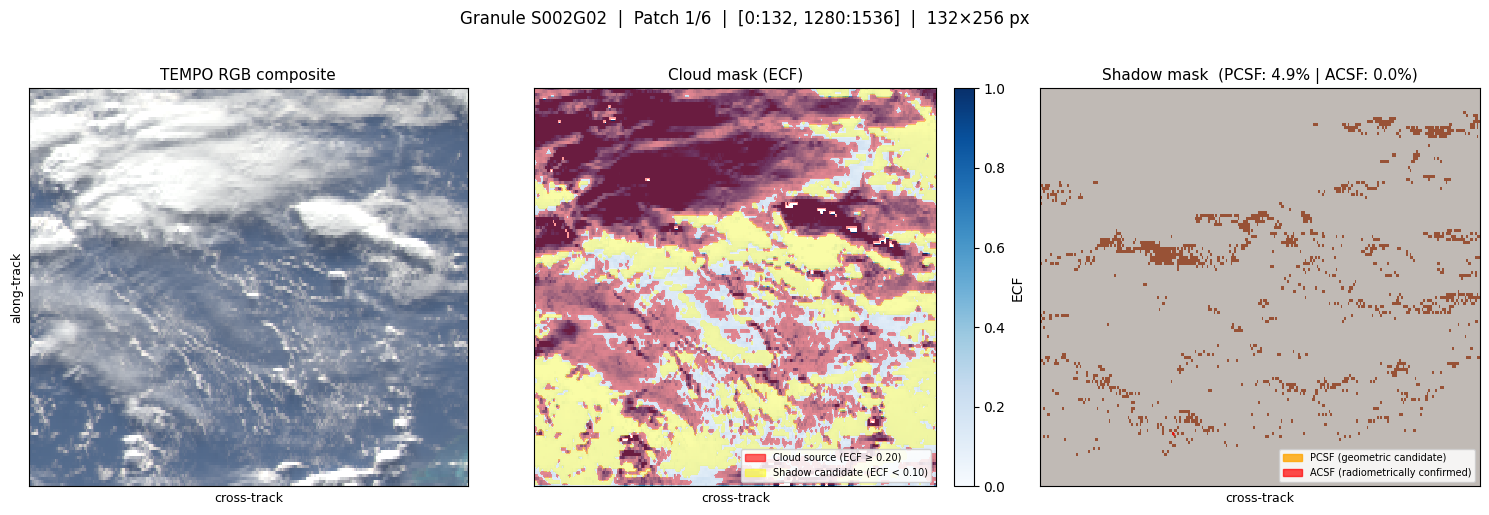

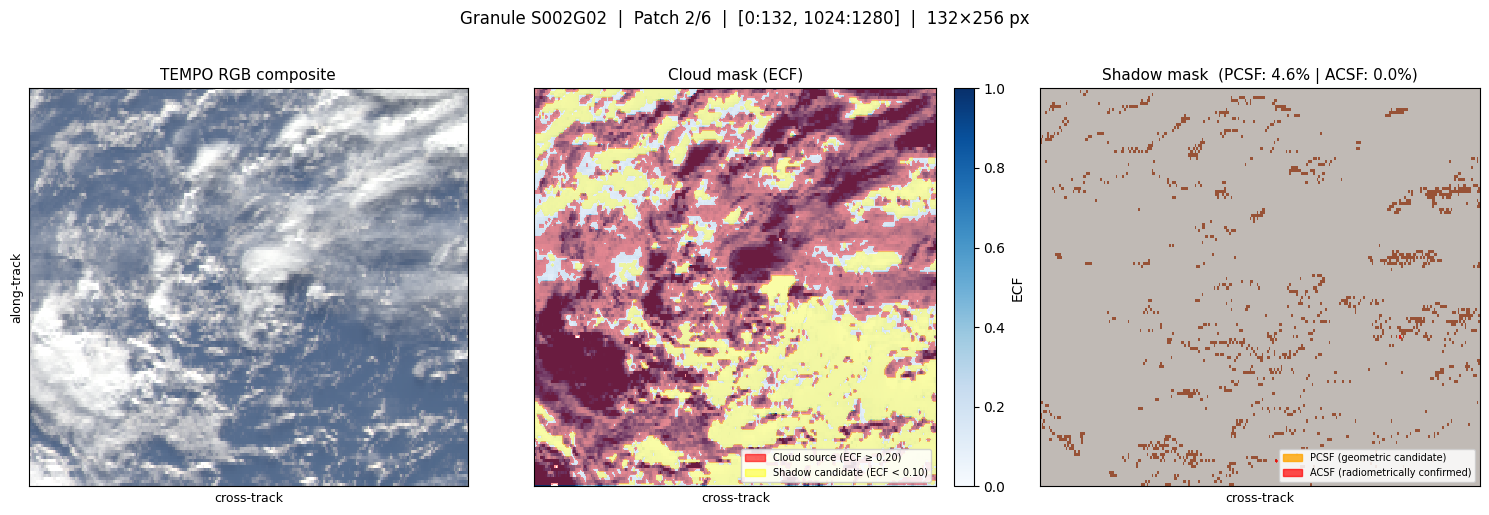

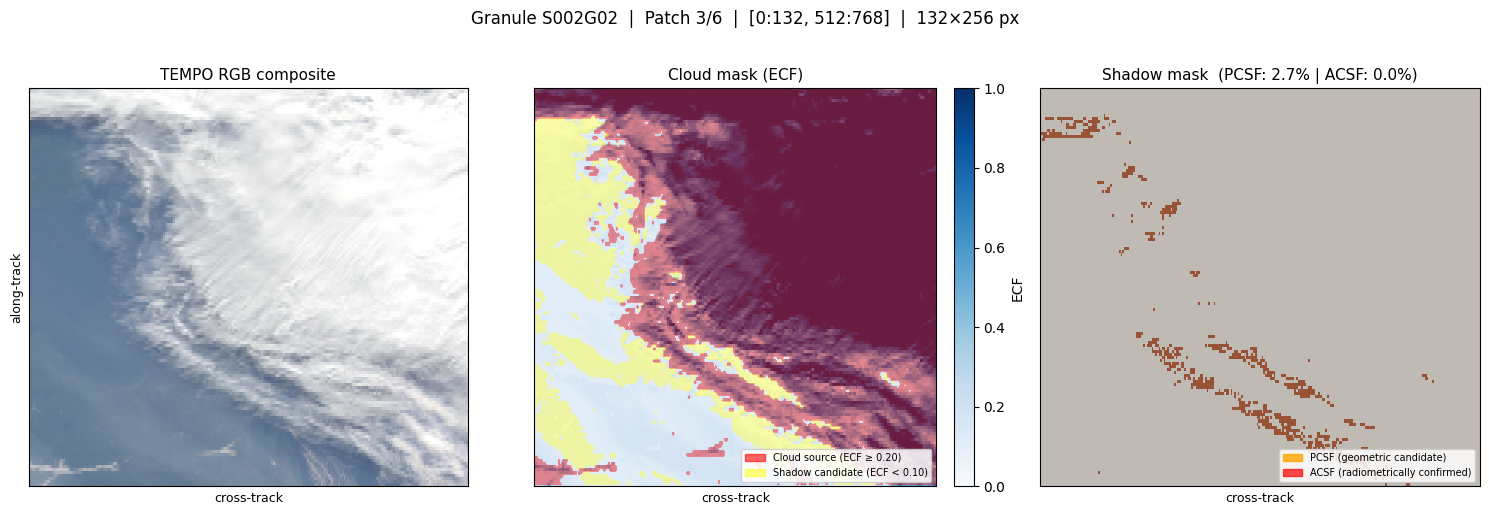

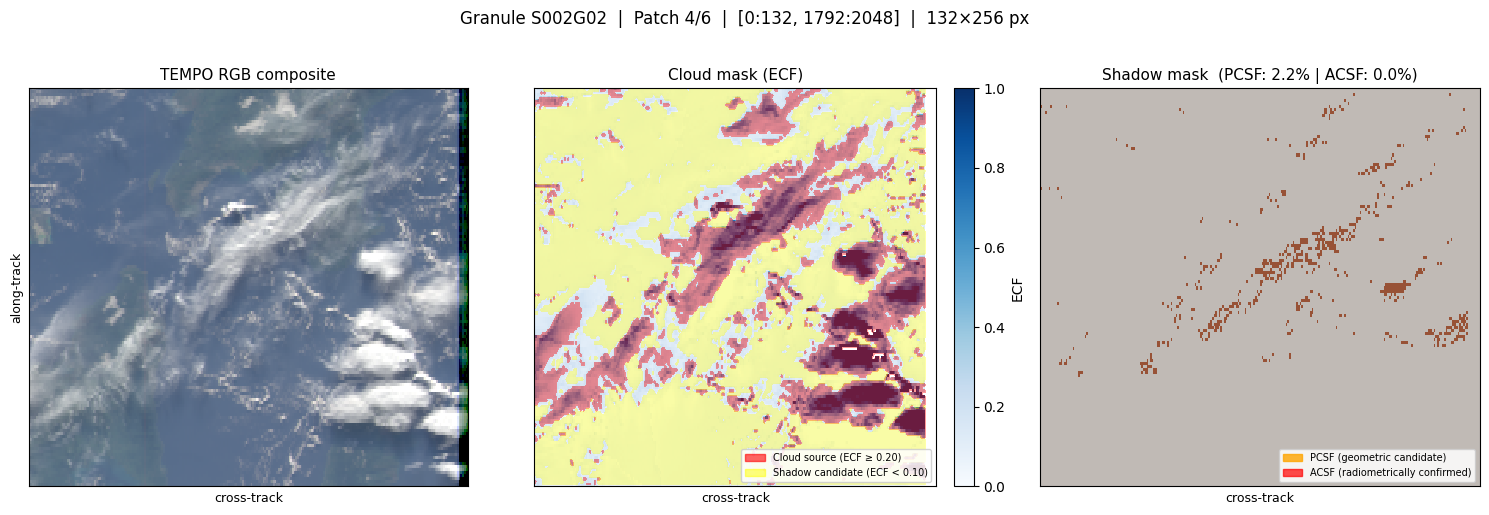

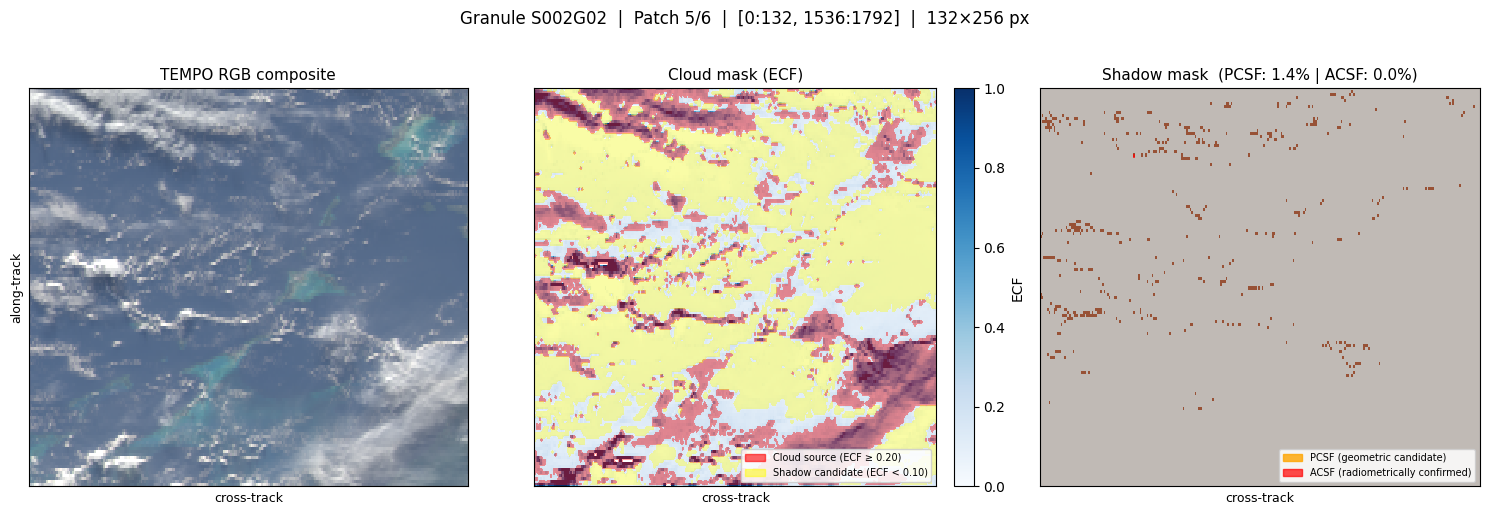

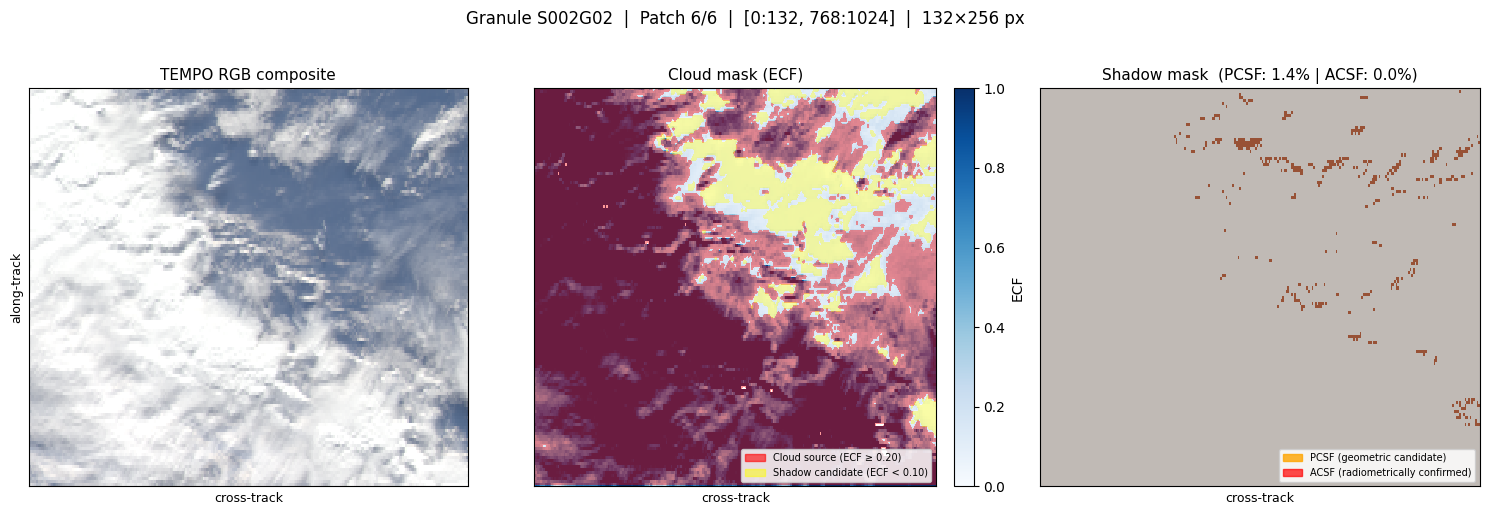

In [18]:
# ============================================================
# Pipeline Execution
# ============================================================

l1b_name, l2_name = GRANULE_PAIRS[ACTIVE_GRANULE_IDX]
l1b_path = L1B_DIR / l1b_name
l2_path  = L2_DIR  / l2_name

# Extract a short granule token for figure titles (e.g. 'S002G02')
granule_token = l1b_name.rsplit("_", 1)[-1].replace(".nc", "")

print(f"L1B: {l1b_path}")
print(f"L2 : {l2_path}")
print()

# --- 1. Load data ---
print("[1/5] Loading granule...")
data = load_granule(l1b_path, l2_path)
print(f"      lat range: {np.nanmin(data['lat']):.2f}\u00b0 to {np.nanmax(data['lat']):.2f}\u00b0 N")
print(f"      lon range: {np.nanmin(data['lon']):.2f}\u00b0 to {np.nanmax(data['lon']):.2f}\u00b0 E")
print(f"      cloud_height range: {np.nanmin(data['cloud_height']):.0f} m to {np.nanmax(data['cloud_height']):.0f} m")
print()

# --- 2. Quality mask ---
print("[2/5] Building quality mask...")
quality_mask = build_quality_mask(data)
n_valid = int(np.sum(quality_mask))
n_total = N_MIRROR_STEPS * N_XTRACK
print(f"      Valid pixels: {n_valid} / {n_total} ({n_valid/n_total:.1%})")
print()

# --- 3. PCSF ---
print("[3/5] Computing PCSF (per-pixel shadow projection)...")
print("      Note: per-pixel Python loop — may take 1–3 minutes.")
pcsf = compute_pcsf(data, quality_mask)
print()

# --- 4. ACSF ---
print("[4/5] Computing ACSF (radiometric confirmation)...")
acsf = compute_acsf(data, pcsf, quality_mask)
print()

# --- 5. Coverage statistics ---
n_source    = int(np.sum((data["cloud_fraction"] >= ECF_SOURCE_THRESH) & quality_mask))
n_candidate = int(np.sum((data["cloud_fraction"] < ECF_CANDIDATE_THRESH) & quality_mask))
n_pcsf      = int(np.sum(pcsf))
n_acsf      = int(np.sum(acsf))

print("=" * 55)
print(f"Granule: {l1b_name}")
print(f"  Grid            : {N_MIRROR_STEPS} x {N_XTRACK} = {n_total} pixels")
print(f"  Valid (QA mask) : {n_valid:6d}  ({n_valid/n_total:.1%})")
print(f"  Cloud source    : {n_source:6d}  ({n_source/n_total:.1%})  [ECF >= {ECF_SOURCE_THRESH:.2f}]")
print(f"  Shadow candidate: {n_candidate:6d}  ({n_candidate/n_total:.1%})  [ECF <  {ECF_CANDIDATE_THRESH:.2f}]")
if n_candidate > 0:
    print(f"  PCSF flagged    : {n_pcsf:6d}  ({n_pcsf/n_candidate:.1%} of candidates)")
else:
    print(f"  PCSF flagged    : {n_pcsf:6d}")
if n_pcsf > 0:
    print(f"  ACSF confirmed  : {n_acsf:6d}  ({n_acsf/n_pcsf:.1%} of PCSF)")
else:
    print(f"  ACSF confirmed  : {n_acsf:6d}")
print("=" * 55)
print()

# --- 6. Visualize diagnostic patches ---
print("[5/5] Finding and plotting diagnostic patches...")
patches = find_shadow_patches(pcsf)
print(f"      Found {len(patches)} patch(es) with PCSF >= {SHADOW_FRAC_MIN:.0%}")
print()
plot_shadow_patches(data, pcsf, acsf, patches, granule_name=granule_token)

(array([23024.,  2310.,  2364.,  2438.,  2503.,  2769.,  2979.,  3388.,
         3840.,  4327.,  4396.,  4288.,  4170.,  4032.,  3799.,  3413.,
         3313.,  3241.,  3063.,  2943.,  2923.,  2900.,  2855.,  2836.,
         2735.,  2800.,  2649.,  2702.,  2560.,  2749.,  2600.,  2422.,
         2440.,  2397.,  2269.,  2325.,  2252.,  2065.,  2176.,  2029.,
         1925.,  1958.,  1988.,  1980.,  1933.,  1943.,  1951.,  1972.,
         1974.,  1988.,  1994.,  1877.,  1993.,  1898.,  1778.,  1800.,
         1833.,  1749.,  1715.,  1701.,  1678.,  1634.,  1598.,  1544.,
         1550.,  1673.,  1519.,  1421.,  1409.,  1424.,  1314.,  1285.,
         1325.,  1252.,  1171.,  1138.,  1130.,  1143.,  1112.,  1082.,
         1068.,   961.,   944.,   900.,   909.,   864.,   821.,   850.,
          852.,   835.,   896.,   931.,   867.,   961.,   903.,   901.,
          897.,   882.,   887., 31133.]),
 array([   0.,   80.,  160.,  240.,  320.,  400.,  480.,  560.,  640.,
         720.,  800.,  

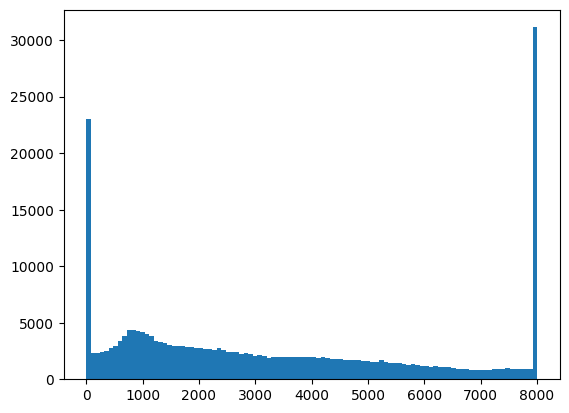

In [21]:
plt.hist(data['cloud_height'].flatten(), bins=100)

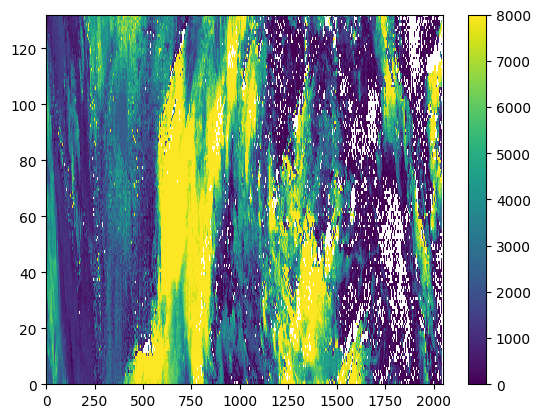

In [23]:
plt.pcolormesh(data['cloud_height'])
plt.colorbar()